🚗 Road Accident Severity Prediction

A Machine Learning project that predicts the severity of road accidents using historical accident records. The project analyzes driver information, road conditions, weather, vehicle details, and accident-related factors to classify accidents into different severity levels.

In [1]:
import numpy as np
import matplotlib.pyplot as plt
import pandas as pd
import seaborn as sns

import warnings

warnings.filterwarnings("ignore")

In [2]:
df = pd.read_csv("RTA Dataset.csv")
df.head()

,Time,Day_of_week,Age_band_of_driver,Sex_of_driver,Educational_level,Vehicle_driver_relation,Driving_experience,Type_of_vehicle,Owner_of_vehicle,Service_year_of_vehicle,...,Vehicle_movement,Casualty_class,Sex_of_casualty,Age_band_of_casualty,Casualty_severity,Work_of_casuality,Fitness_of_casuality,Pedestrian_movement,Cause_of_accident,Accident_severity
0,17:02:00,Monday,18-30,Male,Above high school,Employee,1-2yr,Automobile,Owner,Above 10yr,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Moving Backward,Slight Injury
1,17:02:00,Monday,31-50,Male,Junior high school,Employee,Above 10yr,Public (> 45 seats),Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury
2,17:02:00,Monday,18-30,Male,Junior high school,Employee,1-2yr,Lorry (41?100Q),Owner,NaN,...,Going straight,Driver or rider,Male,31-50,3,Driver,NaN,Not a Pedestrian,Changing lane to the left,Serious Injury
3,1:06:00,Sunday,18-30,Male,Junior high school,Employee,5-10yr,Public (> 45 seats),Governmental,NaN,...,Going straight,Pedestrian,Female,18-30,3,Driver,Normal,Not a Pedestrian,Changing lane to the right,Slight Injury
4,1:06:00,Sunday,18-30,Male,Junior high school,Employee,2-5yr,NaN,Owner,5-10yrs,...,Going straight,na,na,na,na,NaN,NaN,Not a Pedestrian,Overtaking,Slight Injury


In [3]:
df.shape

(12316, 32)

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 12316 entries, 0 to 12315
Data columns (total 32 columns):
 #   Column                       Non-Null Count  Dtype 
---  ------                       --------------  ----- 
 0   Time                         12316 non-null  object
 1   Day_of_week                  12316 non-null  object
 2   Age_band_of_driver           12316 non-null  object
 3   Sex_of_driver                12316 non-null  object
 4   Educational_level            11575 non-null  object
 5   Vehicle_driver_relation      11737 non-null  object
 6   Driving_experience           11487 non-null  object
 7   Type_of_vehicle              11366 non-null  object
 8   Owner_of_vehicle             11834 non-null  object
 9   Service_year_of_vehicle      8388 non-null   object
 10  Defect_of_vehicle            7889 non-null   object
 11  Area_accident_occured        12077 non-null  object
 12  Lanes_or_Medians             11931 non-null  object
 13  Road_allignment              12

In [5]:
df.isnull().sum()

Time                              0
Day_of_week                       0
Age_band_of_driver                0
Sex_of_driver                     0
Educational_level               741
Vehicle_driver_relation         579
Driving_experience              829
Type_of_vehicle                 950
Owner_of_vehicle                482
Service_year_of_vehicle        3928
Defect_of_vehicle              4427
Area_accident_occured           239
Lanes_or_Medians                385
Road_allignment                 142
Types_of_Junction               887
Road_surface_type               172
Road_surface_conditions           0
Light_conditions                  0
Weather_conditions                0
Type_of_collision               155
Number_of_vehicles_involved       0
Number_of_casualties              0
Vehicle_movement                308
Casualty_class                    0
Sex_of_casualty                   0
Age_band_of_casualty              0
Casualty_severity                 0
Work_of_casuality           

In [6]:
df.describe()

,Number_of_vehicles_involved,Number_of_casualties
count,12316.000000,12316.000000
mean,2.040679,1.548149
std,0.688790,1.007179
min,1.000000,1.000000
25%,2.000000,1.000000
50%,2.000000,1.000000
75%,2.000000,2.000000
max,7.000000,8.000000


Handle null values

In [7]:
text_columns = df.select_dtypes(include='object').columns

for col in text_columns:
    df[col] = df[col].fillna("Unknown")

In [8]:
number_columns = df.select_dtypes(include=['int64', 'float64']).columns

for col in number_columns:
    df[col] = df[col].fillna(df[col].median()) 

In [9]:
print("\nTotal missing values after cleaning:", df.isnull().sum().sum())


Total missing values after cleaning: 0


Feature engineering + selection

In [10]:
df['Hour'] = pd.to_datetime(df['Time'], format='%H:%M:%S').dt.hour
df.drop(columns=['Time'], inplace=True)

print(df['Hour'].head())

0    17
1    17
2    17
3     1
4     1
Name: Hour, dtype: int32


drop leakage columns

In [11]:
# These columns describe the casualty AFTER the accident happened.
# Using them would leak the answer into the model.
leakage_cols = [
    'Casualty_class',
    'Sex_of_casualty',
    'Age_band_of_casualty',
    'Casualty_severity',
    'Work_of_casuality',
    'Fitness_of_casuality',
    'Pedestrian_movement'
]

In [12]:
df.shape

(12316, 32)

Encoding

In [14]:
from sklearn.preprocessing import LabelEncoder
le = LabelEncoder()

text_columns = df.select_dtypes(include='object').columns

for col in text_columns:
    df[col] = le.fit_transform(df[col])



In [15]:
df.head

<bound method NDFrame.head of        Day_of_week  Age_band_of_driver  Sex_of_driver  Educational_level  \
0                1                   0              1                  0   
1                1                   1              1                  4   
2                1                   0              1                  4   
3                3                   0              1                  4   
4                3                   0              1                  4   
...            ...                 ...            ...                ...   
12311            6                   1              1                  5   
12312            3                   4              1                  1   
12313            3                   2              1                  4   
12314            3                   0              0                  4   
12315            3                   0              1                  4   

       Vehicle_driver_relation  Driving_experience  Type_

In [16]:
X = df.drop('Accident_severity', axis=1)
y = df['Accident_severity']

Data Spliting

In [17]:
from sklearn.model_selection import train_test_split

X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.25, random_state=42, stratify=y)

In [18]:
print("Training Data:", X_train.shape)
print("Testing Data:", X_test.shape)

Training Data: (9237, 31)
Testing Data: (3079, 31)


Training Model

In [19]:
from sklearn.linear_model import LogisticRegression
from sklearn.tree import DecisionTreeClassifier
from sklearn.ensemble import RandomForestClassifier

In [20]:
lr = LogisticRegression(class_weight='balanced', max_iter=1000)

lr.fit(X_train, y_train)

LogisticRegression(class_weight='balanced', max_iter=1000)

In [21]:
dt = DecisionTreeClassifier(class_weight='balanced', random_state=42)

dt.fit(X_train, y_train)

DecisionTreeClassifier(class_weight='balanced', random_state=42)

In [22]:
rf = RandomForestClassifier(
    n_estimators=100,
    class_weight='balanced',
    random_state=42
)

rf.fit(X_train, y_train)

RandomForestClassifier(class_weight='balanced', random_state=42)

: Evaluate the Models

In [23]:
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

• Accuracy — the percentage of predictions that were correct overall.

• Confusion Matrix — a table that shows exactly which classes the model correctly predicted, and
which classes it confused with each other.

• Classification Report — shows Precision, Recall, and F1-score for each severity class separately

Predictions

In [24]:
lr_pred = lr.predict(X_test)
dt_pred = dt.predict(X_test)
rf_pred = rf.predict(X_test)

In [25]:
lr_acc = accuracy_score(y_test, lr_pred)
dt_acc = accuracy_score(y_test, dt_pred)
rf_acc = accuracy_score(y_test, rf_pred)

print("Logistic Regression Accuracy:", lr_acc)
print("Decision Tree Accuracy:", dt_acc)
print("Random Forest Accuracy:", rf_acc)

Logistic Regression Accuracy: 0.49691458265670674
Decision Tree Accuracy: 0.7752517050990582
Random Forest Accuracy: 0.8467034751542709


In [26]:
print("Logistic Regression Report")
print(classification_report(y_test, lr_pred))

Logistic Regression Report
              precision    recall  f1-score   support

           0       0.02      0.33      0.04        39
           1       0.17      0.33      0.23       436
           2       0.88      0.53      0.66      2604

    accuracy                           0.50      3079
   macro avg       0.36      0.40      0.31      3079
weighted avg       0.77      0.50      0.59      3079



In [28]:

print("Decision Tree Report")
print(classification_report(y_test, dt_pred))



Decision Tree Report
              precision    recall  f1-score   support

           0       0.09      0.08      0.08        39
           1       0.28      0.28      0.28       436
           2       0.87      0.87      0.87      2604

    accuracy                           0.78      3079
   macro avg       0.41      0.41      0.41      3079
weighted avg       0.78      0.78      0.78      3079



In [29]:
print("Random Forest Report")
print(classification_report(y_test, rf_pred))

Random Forest Report
              precision    recall  f1-score   support

           0       0.00      0.00      0.00        39
           1       1.00      0.01      0.01       436
           2       0.85      1.00      0.92      2604

    accuracy                           0.85      3079
   macro avg       0.62      0.34      0.31      3079
weighted avg       0.86      0.85      0.78      3079



Accuracy Comparision

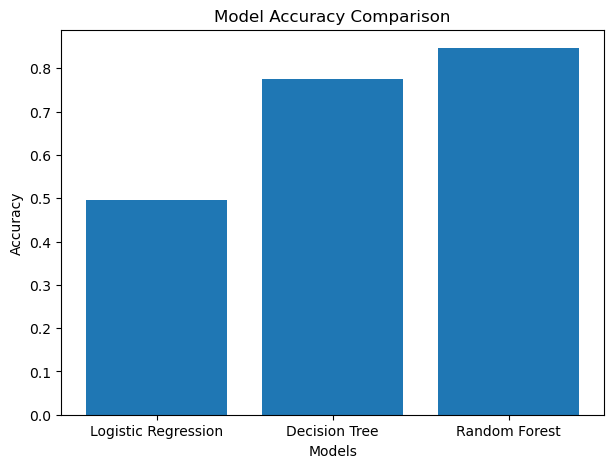

In [30]:
models = ["Logistic Regression", "Decision Tree", "Random Forest"]
accuracy = [lr_acc, dt_acc, rf_acc]

plt.figure(figsize=(7,5))
plt.bar(models, accuracy)

plt.title("Model Accuracy Comparison")
plt.xlabel("Models")
plt.ylabel("Accuracy")

plt.show()

Confusion Matrix

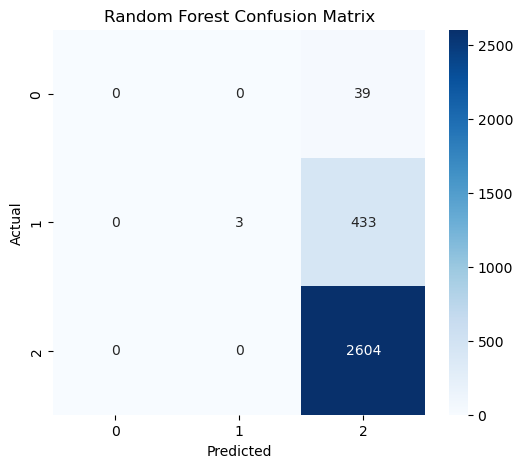

In [31]:
import matplotlib.pyplot as plt
import seaborn as sns

cm = confusion_matrix(y_test, rf_pred)

plt.figure(figsize=(6,5))
sns.heatmap(cm, annot=True, fmt="d", cmap="Blues")

plt.title("Random Forest Confusion Matrix")
plt.xlabel("Predicted")
plt.ylabel("Actual")

plt.show()

Feature Importance

In [ ]:
importances = rf.feature_importances_


feature_importance_df = pd.DataFrame({
    'Feature': X.columns,
    'Importance': importances
}).sort_values(by='Importance', ascending=False)

print(feature_importance_df)


                        Feature  Importance
30                         Hour    0.086953
20         Number_of_casualties    0.081410
29            Cause_of_accident    0.061267
0                   Day_of_week    0.057970
6               Type_of_vehicle    0.055584
5            Driving_experience    0.044986
1            Age_band_of_driver    0.044333
10        Area_accident_occured    0.044156
19  Number_of_vehicles_involved    0.042381
13            Types_of_Junction    0.042020
21             Vehicle_movement    0.038767
11             Lanes_or_Medians    0.038380
8       Service_year_of_vehicle    0.033756
3             Educational_level    0.033289
26            Work_of_casuality    0.030291
24         Age_band_of_casualty    0.029891
18            Type_of_collision    0.028226
22               Casualty_class    0.020944
16             Light_conditions    0.019609
9             Defect_of_vehicle    0.018407
12              Road_allignment    0.017566
4       Vehicle_driver_relation 

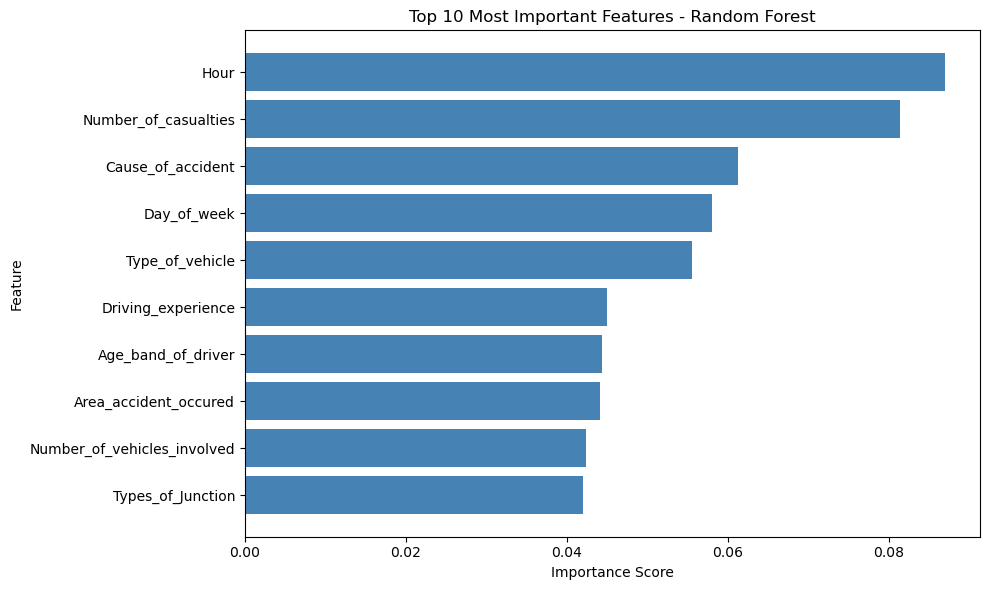

In [33]:
top_10 = feature_importance_df.head(10)

plt.figure(figsize=(10, 6))
plt.barh(top_10['Feature'], top_10['Importance'], color='steelblue')
plt.xlabel('Importance Score')
plt.ylabel('Feature')
plt.title('Top 10 Most Important Features - Random Forest')
plt.gca().invert_yaxis()  # highest importance on top
plt.tight_layout()
plt.show()

Model testing on sample data

In [ ]:
import random

sample_index = random.choice(X_test.index)

sample_row = X_test.loc[[sample_index]]  
actual_value = y_test.loc[sample_index]


predicted_value = rf.predict(sample_row)[0]


print("Encoder currently remembers classes for:", le.classes_)

actual_label = le.inverse_transform([actual_value])[0]
predicted_label = le.inverse_transform([predicted_value])[0]

print(f"\nSample row index: {sample_index}")
print(f"Actual severity:    {actual_label}")
print(f"Predicted severity: {predicted_label}")
print("Correct!" if actual_value == predicted_value else "Incorrect prediction.")

Encoder currently remembers classes for: ['Fatal injury' 'Serious Injury' 'Slight Injury']

Sample row index: 11738
Actual severity:    Slight Injury
Predicted severity: Slight Injury
Correct!


Conclusion

Best Model Selection: Random Forest Classifier achieved the highest overall predictive accuracy (~84.67%) among all evaluated algorithms.  Major Challenge (Class Imbalance): The dataset exhibits extreme class imbalance (the majority of records fall under Class 2 severity). Even with balanced class weights, models heavily favor Class 2, resulting in very low recall/precision for rare accident severity classes (Class 0 and Class 1). 